# Greeks Surface Plots

Delta, Gamma, and Vega as functions of spot price and time to maturity, computed via bump-and-reprice finite differences.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from greeks import delta, gamma, vega, _bs_pricer

In [2]:
K = 100.0
r = 0.05
sigma = 0.2

spots = np.linspace(70, 130, 40)
times = np.linspace(0.05, 2.0, 40)
S_grid, T_grid = np.meshgrid(spots, times)

delta_grid = np.zeros_like(S_grid)
gamma_grid = np.zeros_like(S_grid)
vega_grid = np.zeros_like(S_grid)

for i in range(S_grid.shape[0]):
    for j in range(S_grid.shape[1]):
        S = S_grid[i, j]
        T = T_grid[i, j]
        delta_grid[i, j] = delta(_bs_pricer, S, K, r, sigma, T)
        gamma_grid[i, j] = gamma(_bs_pricer, S, K, r, sigma, T)
        vega_grid[i, j] = vega(_bs_pricer, S, K, r, sigma, T)

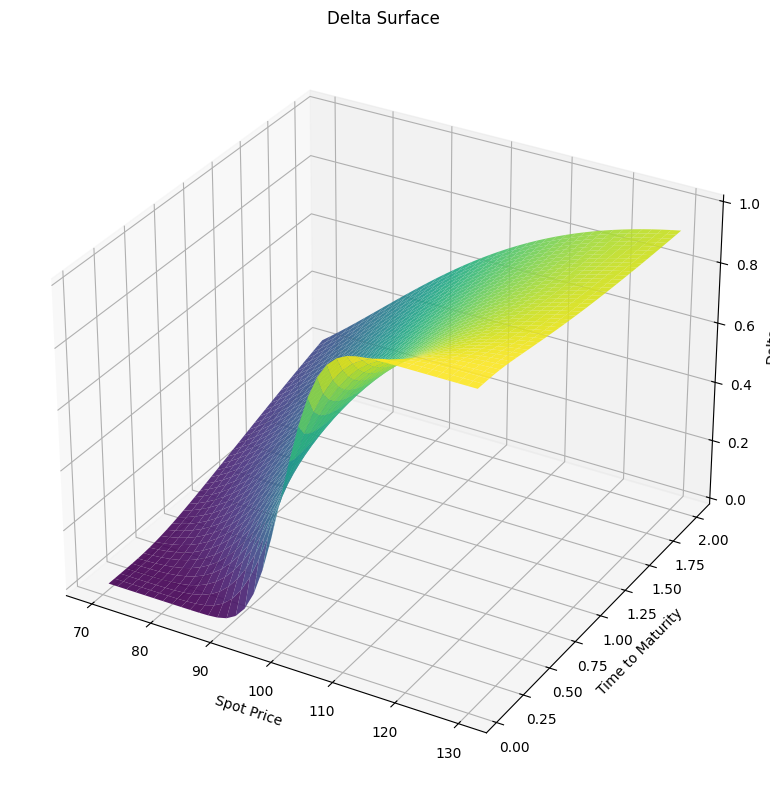

In [3]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, T_grid, delta_grid, cmap='viridis', alpha=0.9)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Time to Maturity')
ax.set_zlabel('Delta')
ax.set_title('Delta Surface')
plt.tight_layout()
plt.savefig('../figures/delta_surface.png', dpi=300)
plt.show()

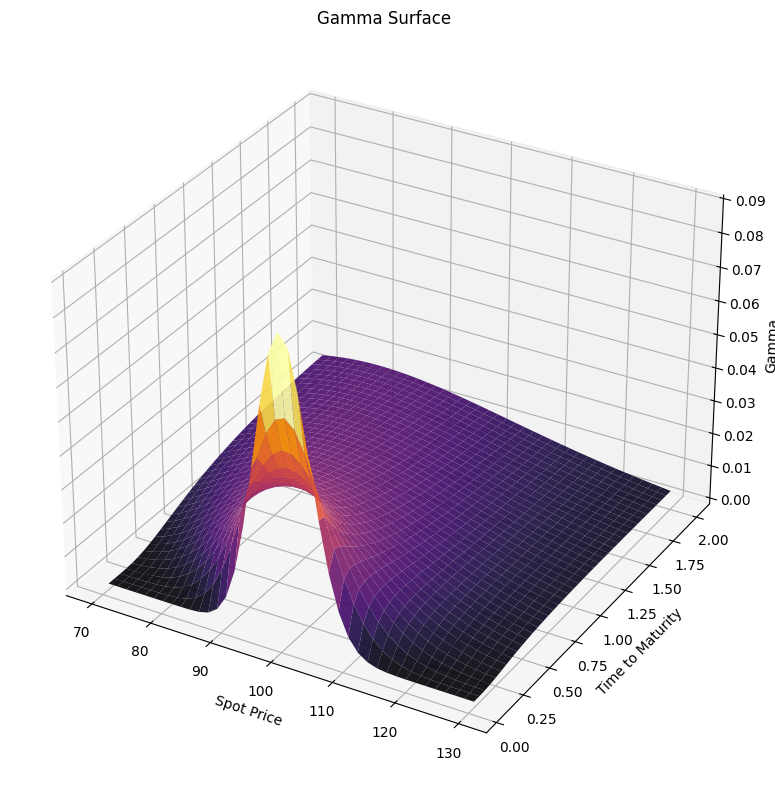

In [4]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, T_grid, gamma_grid, cmap='inferno', alpha=0.9)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Time to Maturity')
ax.set_zlabel('Gamma')
ax.set_title('Gamma Surface')
plt.tight_layout()
plt.savefig('../figures/gamma_surface.png', dpi=300)
plt.show()

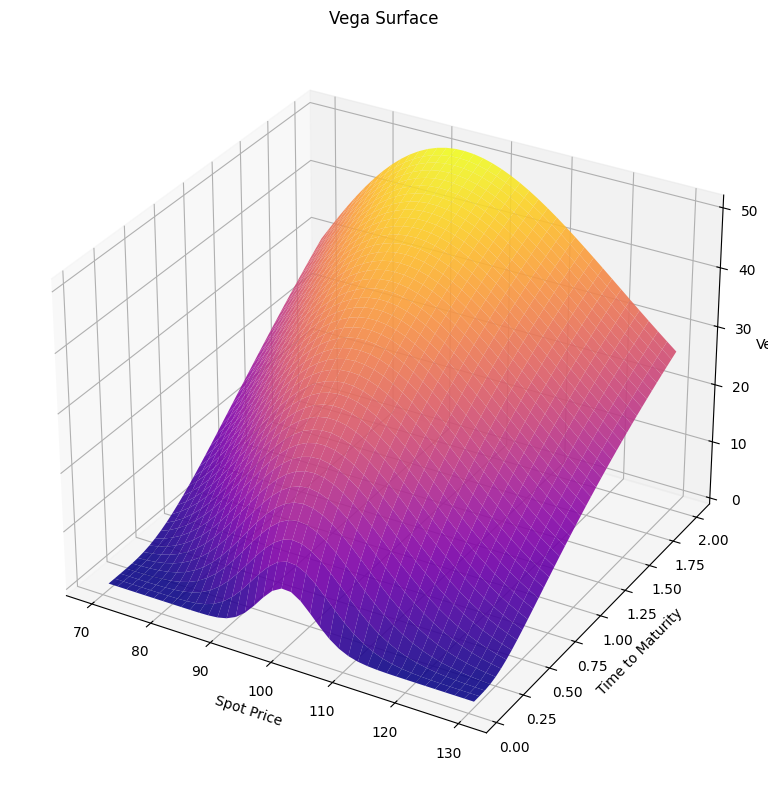

In [5]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, T_grid, vega_grid, cmap='plasma', alpha=0.9)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Time to Maturity')
ax.set_zlabel('Vega')
ax.set_title('Vega Surface')
plt.tight_layout()
plt.savefig('../figures/vega_surface.png', dpi=300)
plt.show()